In [1]:
pip install fastf1

Note: you may need to restart the kernel to use updated packages.


req         WARNING 	DEFAULT CACHE ENABLED! (313.72 MB) C:\Users\colli\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
core        WARNING 	Cannot load lap times for first lap from Ergast. Timing data is not available for this session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for positio

['63', '12', '16', '44', '1', '3', '87', '41', '5', '10']
['RUS', 'ANT', 'LEC', 'HAM', 'NOR', 'VER', 'BEA', 'LIN', 'BOR', 'GAS']


<Axes: xlabel='Driver', ylabel='LapTime(s)'>

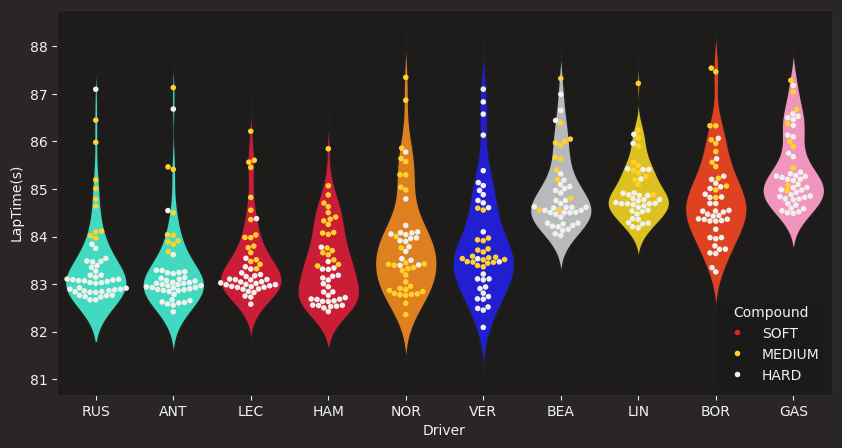

In [2]:
import fastf1
import seaborn as sns
from matplotlib import pyplot as plt

import fastf1
import fastf1.plotting


# Enable Matplotlib patches for plotting timedelta values and load
# FastF1's dark color scheme
fastf1.plotting.setup_mpl(mpl_timedelta_support=True, color_scheme='fastf1')
race = fastf1.get_session(2026, "Australia", 'R')
race.load()
point_finishers = race.drivers[:10]
print(point_finishers)
driver_laps = race.laps.pick_drivers(point_finishers).pick_quicklaps()
driver_laps = driver_laps.reset_index()
finishing_order = [race.get_driver(i)["Abbreviation"] for i in point_finishers]
print(finishing_order)
# create the figure
fig, ax = plt.subplots(figsize=(10, 5))

# Seaborn doesn't have proper timedelta support,
# so we have to convert timedelta to float (in seconds)
driver_laps["LapTime(s)"] = driver_laps["LapTime"].dt.total_seconds()

sns.violinplot(data=driver_laps,
               x="Driver",
               y="LapTime(s)",
               hue="Driver",
               inner=None,
               density_norm="area",
               order=finishing_order,
               palette=fastf1.plotting.get_driver_color_mapping(session=race)
               )

sns.swarmplot(data=driver_laps,
              x="Driver",
              y="LapTime(s)",
              order=finishing_order,
              hue="Compound",
              palette=fastf1.plotting.get_compound_mapping(session=race),
              hue_order=["SOFT", "MEDIUM", "HARD"],
              linewidth=0,
              size=4,
              )
              

In [3]:
ax.set_xlabel("Driver")
ax.set_ylabel("Lap Time (s)")
plt.suptitle("2023 Azerbaijan Grand Prix Lap Time Distributions")
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
core        WARNING 	Cannot load lap times for first lap from Ergast. Timing data is not available for this session.
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1', '3', '87', '41', '5', '10', '31', '23', '30',

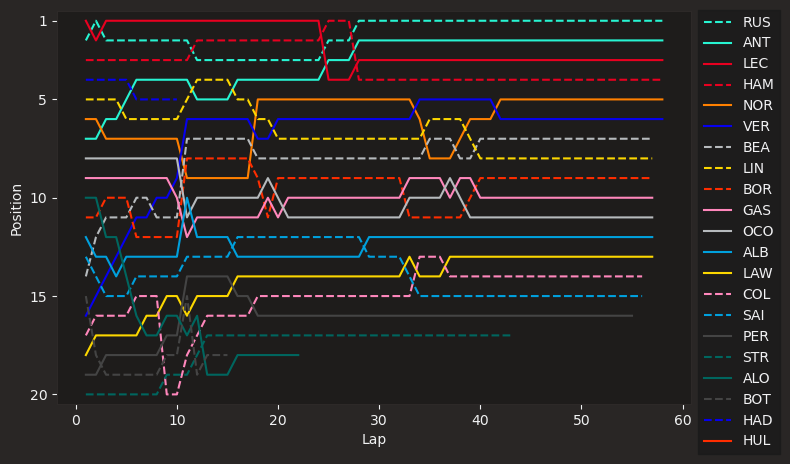

In [4]:
import matplotlib.pyplot as plt

import fastf1.plotting


# Load FastF1's dark color scheme
fastf1.plotting.setup_mpl(mpl_timedelta_support=False, color_scheme='fastf1')
session = fastf1.get_session(2026, 1, 'R')
session.load(telemetry=False, weather=False)

fig, ax = plt.subplots(figsize=(8.0, 4.9))
for drv in session.drivers:
    drv_laps = session.laps.pick_drivers(drv)

    # ✅ On saute les pilotes sans données de tours
    if drv_laps.empty:
        continue

    abb = drv_laps['Driver'].iloc[0]
    style = fastf1.plotting.get_driver_style(identifier=abb,
                                             style=['color', 'linestyle'],
                                             session=session)

    ax.plot(drv_laps['LapNumber'], drv_laps['Position'],
            label=abb, **style)
ax.set_ylim([20.5, 0.5])
ax.set_yticks([1, 5, 10, 15, 20])
ax.set_xlabel('Lap')
ax.set_ylabel('Position')
ax.legend(bbox_to_anchor=(1.0, 1.02), loc='upper left')
plt.tight_layout()
plt.show()

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
core        WARNING 	Cannot load lap times for first lap from Ergast. Timing data is not available for this session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached 

Index(['Mercedes', 'Ferrari', 'McLaren', 'Red Bull Racing', 'Audi',
       'Racing Bulls', 'Haas F1 Team', 'Alpine', 'Williams', 'Aston Martin',
       'Cadillac'],
      dtype='object', name='Team')


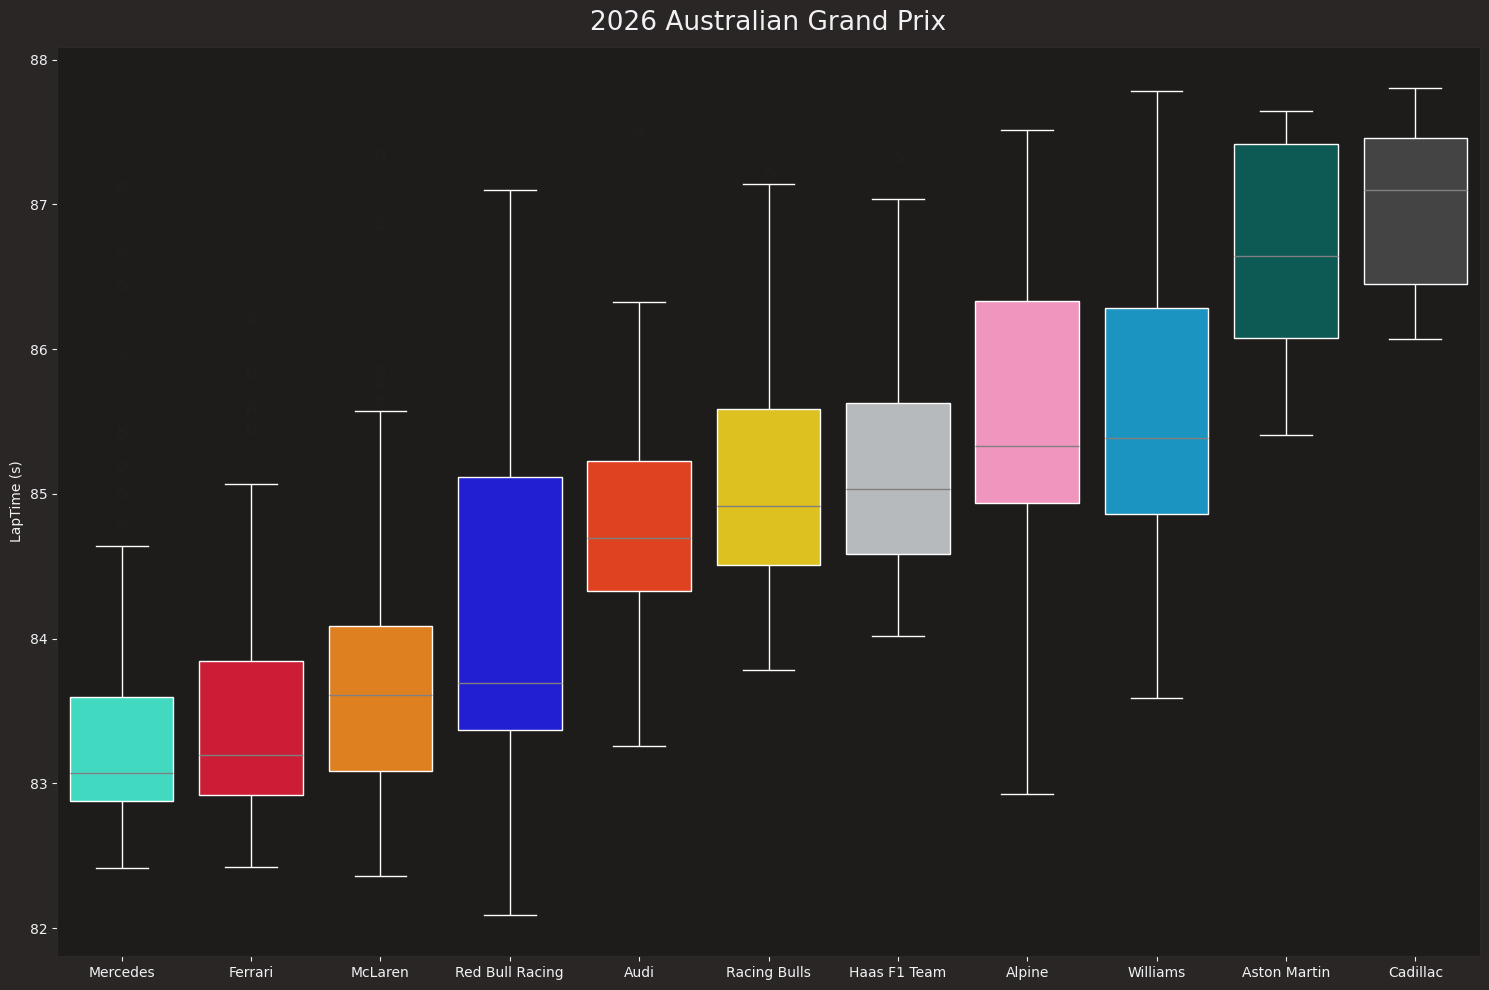

In [5]:
import seaborn as sns
from matplotlib import pyplot as plt

import fastf1
import fastf1.plotting


# Load FastF1's dark color scheme
fastf1.plotting.setup_mpl(mpl_timedelta_support=False, color_scheme='fastf1')
race = fastf1.get_session(2026, 1, 'R')
race.load()
laps = race.laps.pick_quicklaps()
transformed_laps = laps.copy()
transformed_laps.loc[:, "LapTime (s)"] = laps["LapTime"].dt.total_seconds()

# order the team from the fastest (lowest median lap time) tp slower
team_order = (
    transformed_laps[["Team", "LapTime (s)"]]
    .groupby("Team")
    .median()["LapTime (s)"]
    .sort_values()
    .index
)
print(team_order)

# make a color palette associating team names to hex codes
team_palette = {team: fastf1.plotting.get_team_color(team, session=race)
                for team in team_order}
fig, ax = plt.subplots(figsize=(15, 10))
sns.boxplot(
    data=transformed_laps,
    x="Team",
    y="LapTime (s)",
    hue="Team",
    order=team_order,
    palette=team_palette,
    whiskerprops=dict(color="white"),
    boxprops=dict(edgecolor="white"),
    medianprops=dict(color="grey"),
    capprops=dict(color="white"),
)

plt.title("2026 Australian Grand Prix")
plt.grid(visible=False)

# x-label is redundant
ax.set(xlabel=None)
plt.tight_layout()
plt.show()

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 18
core        WARNING 	No lap data for driver 55
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 18)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 55)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_c

['RUS' 'ANT' 'HAD' 'LEC' 'PIA' 'NOR' 'HAM' 'LAW' 'LIN' 'BOR' 'HUL' 'BEA'
 'OCO' 'GAS' 'ALB' 'COL' 'ALO' 'PER' 'BOT' 'VER']
   Driver                LapTime           LapTimeDelta
0     RUS 0 days 00:01:18.518000        0 days 00:00:00
1     ANT 0 days 00:01:18.811000 0 days 00:00:00.293000
2     HAD 0 days 00:01:19.303000 0 days 00:00:00.785000
3     LEC 0 days 00:01:19.327000 0 days 00:00:00.809000
4     PIA 0 days 00:01:19.380000 0 days 00:00:00.862000
5     NOR 0 days 00:01:19.475000 0 days 00:00:00.957000
6     HAM 0 days 00:01:19.478000 0 days 00:00:00.960000
7     LIN 0 days 00:01:19.971000 0 days 00:00:01.453000
8     LAW 0 days 00:01:19.994000 0 days 00:00:01.476000
9     BOR 0 days 00:01:20.221000 0 days 00:00:01.703000
10    HUL 0 days 00:01:20.303000 0 days 00:00:01.785000
11    BEA 0 days 00:01:20.311000 0 days 00:00:01.793000
12    OCO 0 days 00:01:20.491000 0 days 00:00:01.973000
13    GAS 0 days 00:01:20.501000 0 days 00:00:01.983000
14    ALB 0 days 00:01:20.941000 0 da

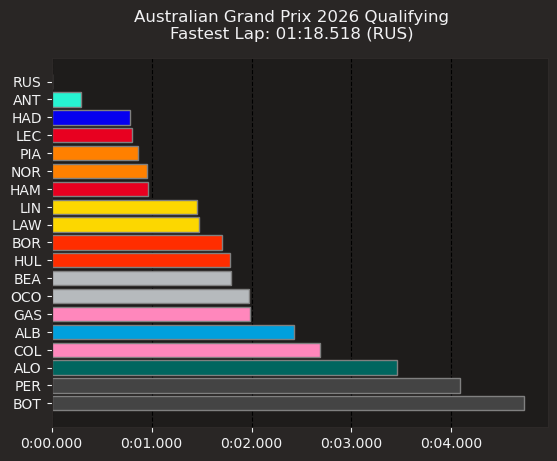

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from timple.timedelta import strftimedelta

import fastf1
import fastf1.plotting
from fastf1.core import Laps


# Enable Matplotlib patches for plotting timedelta values
fastf1.plotting.setup_mpl(mpl_timedelta_support=True, color_scheme=None)


session = fastf1.get_session(2026, 'Australia', 'Q')
session.load()
drivers = pd.unique(session.laps['Driver'])
print(drivers)
list_fastest_laps = list()
list_fastest_laps = list()
for drv in drivers:
    drvs_fastest_lap = session.laps.pick_drivers(drv).pick_fastest()
    
    # ✅ On ignore les pilotes sans tour rapide valide
    if drvs_fastest_lap is not None:
        list_fastest_laps.append(drvs_fastest_lap)

fastest_laps = Laps(list_fastest_laps) \
    .sort_values(by='LapTime') \
    .reset_index(drop=True)
pole_lap = fastest_laps.pick_fastest()
fastest_laps['LapTimeDelta'] = fastest_laps['LapTime'] - pole_lap['LapTime']
print(fastest_laps[['Driver', 'LapTime', 'LapTimeDelta']])
team_colors = list()
for index, lap in fastest_laps.iterlaps():
    color = fastf1.plotting.get_team_color(lap['Team'], session=session)
    team_colors.append(color)
fig, ax = plt.subplots()
ax.barh(fastest_laps.index, fastest_laps['LapTimeDelta'],
        color=team_colors, edgecolor='grey')
ax.set_yticks(fastest_laps.index)
ax.set_yticklabels(fastest_laps['Driver'])

# show fastest at the top
ax.invert_yaxis()

# draw vertical lines behind the bars
ax.set_axisbelow(True)
ax.xaxis.grid(True, which='major', linestyle='--', color='black', zorder=-1000)
lap_time_string = strftimedelta(pole_lap['LapTime'], '%m:%s.%ms')

plt.suptitle(f"{session.event['EventName']} {session.event.year} Qualifying\n"
             f"Fastest Lap: {lap_time_string} ({pole_lap['Driver']})")

plt.show()

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 18
core        WARNING 	No lap data for driver 55
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 18)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 55)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_c

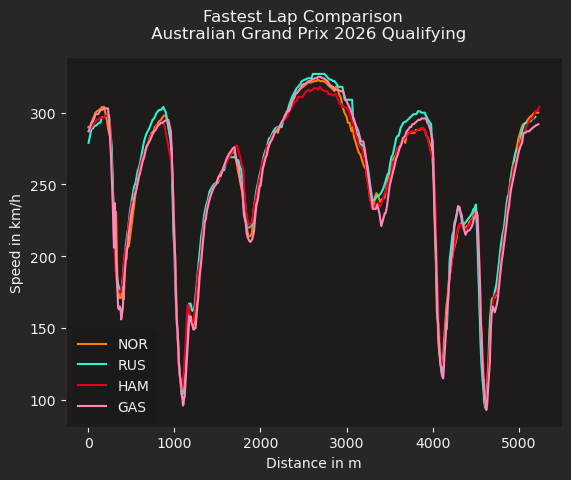

In [7]:
import matplotlib.pyplot as plt

import fastf1.plotting


# Enable Matplotlib patches for plotting timedelta values and load
# FastF1's dark color scheme
fastf1.plotting.setup_mpl(mpl_timedelta_support=True, color_scheme='fastf1')

# load a session and its telemetry data
session = fastf1.get_session(2026, 'Australia', 'Q')
session.load()
rus_lap = session.laps.pick_drivers('RUS').pick_fastest()
ham_lap = session.laps.pick_drivers('HAM').pick_fastest()
nor_lap = session.laps.pick_drivers('NOR').pick_fastest()
gas_lap = session.laps.pick_drivers('GAS').pick_fastest()

nor_tel = nor_lap.get_car_data().add_distance()
rus_tel = rus_lap.get_car_data().add_distance()
ham_tel = ham_lap.get_car_data().add_distance()
gas_tel = gas_lap.get_car_data().add_distance()
mer_color = fastf1.plotting.get_team_color(rus_lap['Team'], session=session)
fer_color = fastf1.plotting.get_team_color(ham_lap['Team'], session=session)
mcl_color = fastf1.plotting.get_team_color(nor_lap['Team'], session=session)
gri_color = fastf1.plotting.get_team_color(gas_lap['Team'], session=session)

fig, ax = plt.subplots()
ax.plot(nor_tel['Distance'], nor_tel['Speed'], color=mcl_color, label='NOR')
ax.plot(rus_tel['Distance'], rus_tel['Speed'], color=mer_color, label='RUS')
ax.plot(ham_tel['Distance'], ham_tel['Speed'], color=fer_color, label='HAM')
ax.plot(gas_tel['Distance'], gas_tel['Speed'], color=gri_color, label='GAS')

ax.set_xlabel('Distance in m')
ax.set_ylabel('Speed in km/h')

ax.legend()
plt.suptitle(f"Fastest Lap Comparison \n "
             f"{session.event['EventName']} {session.event.year} Qualifying")

plt.show()

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
core        WARNING 	Cannot load lap times for first lap from Ergast. Timing data is not available for this session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached 

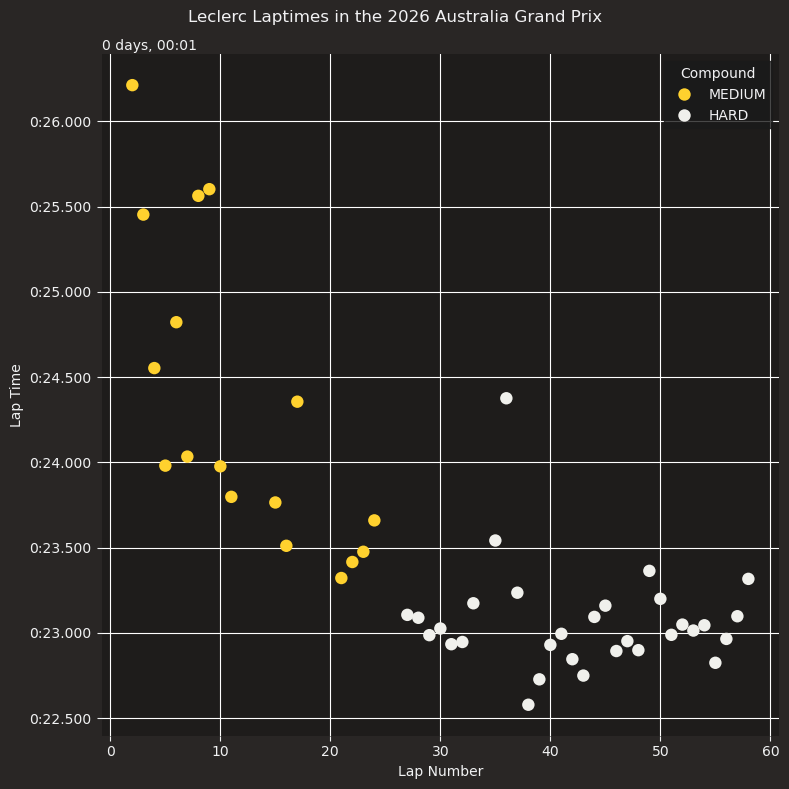

In [8]:
import seaborn as sns
from matplotlib import pyplot as plt

import fastf1
import fastf1.plotting


# Enable Matplotlib patches for plotting timedelta values and load
# FastF1's dark color scheme
fastf1.plotting.setup_mpl(mpl_timedelta_support=True, color_scheme='fastf1')
race = fastf1.get_session(2026, "Australia", 'R')
race.load()
driver_laps = race.laps.pick_drivers("LEC").pick_quicklaps().reset_index()
fig, ax = plt.subplots(figsize=(8, 8))

sns.scatterplot(data=driver_laps,
                x="LapNumber",
                y="LapTime",
                ax=ax,
                hue="Compound",
                palette=fastf1.plotting.get_compound_mapping(session=race),
                s=80,
                linewidth=0,
                legend='auto')
ax.set_xlabel("Lap Number")
ax.set_ylabel("Lap Time")

# The y-axis increases from bottom to top by default
# Since we are plotting time, it makes sense to invert the axis
ax.invert_yaxis()
plt.suptitle("Leclerc Laptimes in the 2026 Australia Grand Prix")

# Turn on major grid lines
plt.grid(color='w', which='major', axis='both')
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
core        WARNING 	Cannot load lap times for first lap from Ergast. Timing data is not available for this session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached 

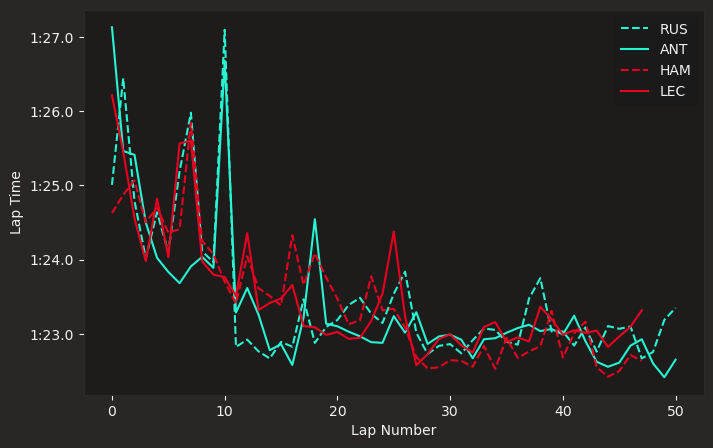

In [9]:
from matplotlib import pyplot as plt

import fastf1
from fastf1 import plotting


# Enable Matplotlib patches for plotting timedelta values and load
# FastF1's dark color scheme
fastf1.plotting.setup_mpl(mpl_timedelta_support=True, color_scheme='fastf1')
race = fastf1.get_session(2026, "Australia", 'R')
race.load()

fig, ax = plt.subplots(figsize=(8, 5))

for driver in ('RUS', 'ANT', 'HAM', 'LEC'):
    laps = race.laps.pick_drivers(driver).pick_quicklaps().reset_index()
    style = plotting.get_driver_style(identifier=driver,
                                      style=['color', 'linestyle'],
                                      session=race)
    ax.plot(laps['LapTime'], **style, label=driver)

# add axis labels and a legend
ax.set_xlabel("Lap Number")
ax.set_ylabel("Lap Time")
ax.legend()


In [10]:
import pandas as pd
import plotly.express as px
from plotly.io import show

from fastf1.ergast import Ergast
ergast = Ergast()
races = ergast.get_race_schedule(2025)  # Races in year 2026
results = []

# For each race in the season
for rnd, race in races['raceName'].items():

    # Get results. Note that we use the round no. + 1, because the round no.
    # starts from one (1) instead of zero (0)
    temp = ergast.get_race_results(season=2025, round=rnd + 1)
    temp = temp.content[0]

    # If there is a sprint, get the results as well
    sprint = ergast.get_sprint_results(season=2025, round=rnd + 1)
    if sprint.content and sprint.description['round'][0] == rnd + 1:
        temp = pd.merge(temp, sprint.content[0], on='driverCode', how='left')
        # Add sprint points and race points to get the total
        temp['points'] = temp['points_x'] + temp['points_y']
        temp.drop(columns=['points_x', 'points_y'], inplace=True)

    # Add round no. and grand prix name
    temp['round'] = rnd + 1
    temp['race'] = race.removesuffix(' Grand Prix')
    temp = temp[['round', 'race', 'driverCode', 'points']]  # Keep useful cols.
    results.append(temp)

# Append all races into a single dataframe
results = pd.concat(results)
races = results['race'].drop_duplicates()
results = results.pivot(index='driverCode', columns='round', values='points')
# Here we have a 22-by-22 matrix (22 races and 22 drivers, incl. DEV and HUL)

# Rank the drivers by their total points
results['total_points'] = results.sum(axis=1)
results = results.sort_values(by='total_points', ascending=False)
results.drop(columns='total_points', inplace=True)

# Use race name, instead of round no., as column names
results.columns = races
fig = px.imshow(
    results,
    text_auto=True,
    aspect='auto',  # Automatically adjust the aspect ratio
    color_continuous_scale=[[0,    'rgb(198, 219, 239)'],  # Blue scale
                            [0.25, 'rgb(107, 174, 214)'],
                            [0.5,  'rgb(33,  113, 181)'],
                            [0.75, 'rgb(8,   81,  156)'],
                            [1,    'rgb(8,   48,  107)']],
    labels={'x': 'Race',
            'y': 'Driver',
            'color': 'Points'}       # Change hover texts
)
fig.update_xaxes(title_text='')      # Remove axis titles
fig.update_yaxes(title_text='')
fig.update_yaxes(tickmode='linear')  # Show all ticks, i.e. driver names
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='LightGrey',
                 showline=False,
                 tickson='boundaries')              # Show horizontal grid only
fig.update_xaxes(showgrid=False, showline=False)    # And remove vertical grid
fig.update_layout(plot_bgcolor='rgba(0,0,0,0)')     # White background
fig.update_layout(coloraxis_showscale=False)        # Remove legend
fig.update_layout(xaxis=dict(side='top'))           # x-axis on top
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))  # Remove border margins
fig
show(fig)